Loaded 70,088 rows


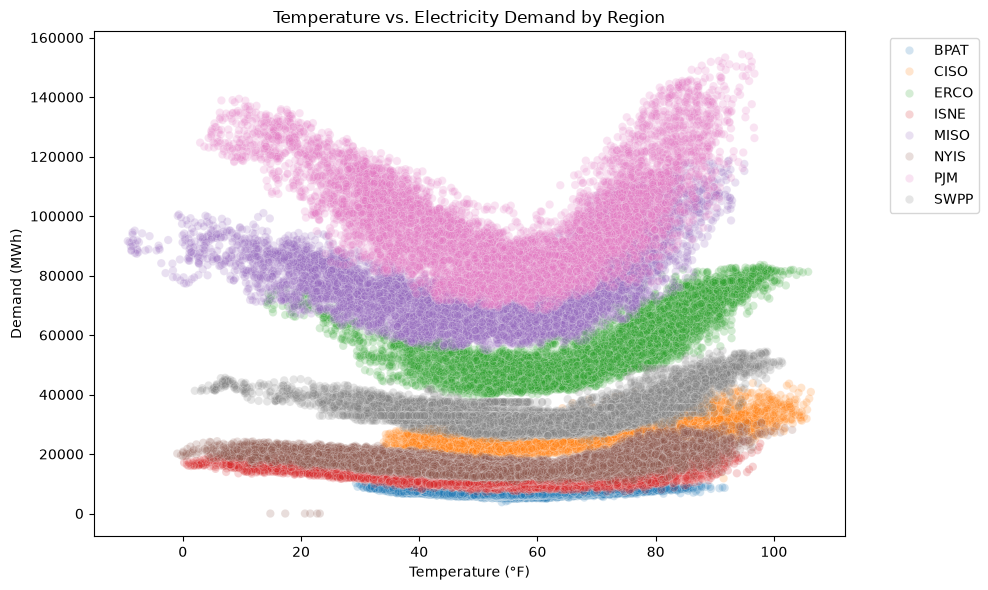

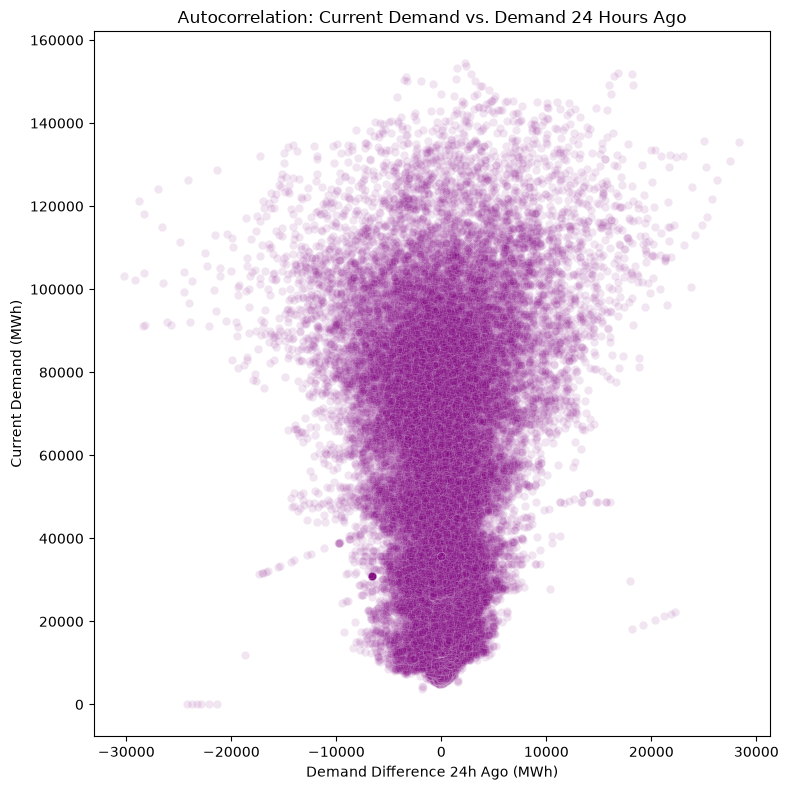

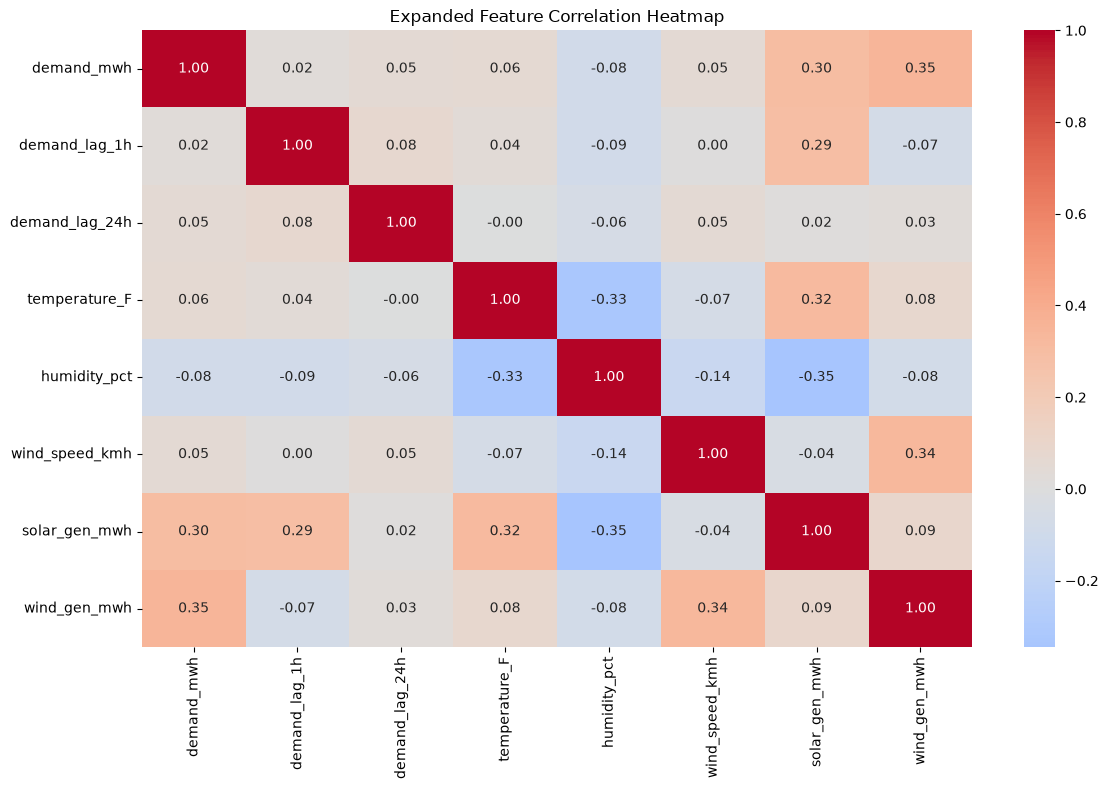

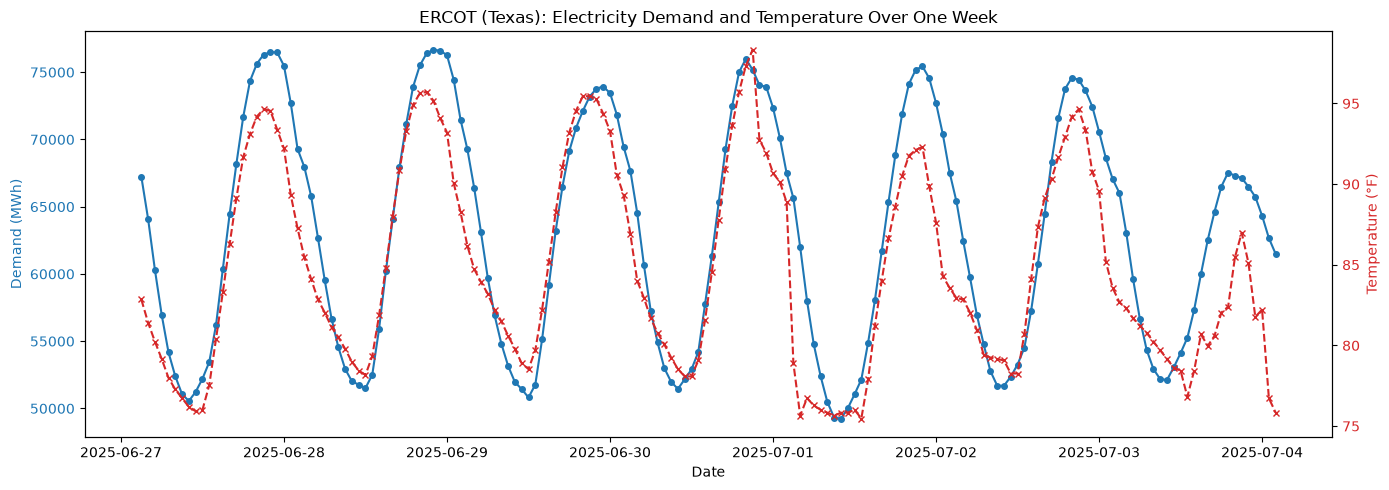

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up the path matching your project structure
#root =  "Code" / "AI4ALL-Group-11A"
data_path = root / "data" / "processed" / "eia_with_features.csv"

# Load the NEW feature-rich dataset
df = pd.read_csv("../data/processed/eia_with_features.csv", parse_dates=["datetime_utc"])
print(f"Loaded {len(df):,} rows")

# ---------------------------------------------------------
# 1. Temperature vs. Demand (The "Duck" or "U" Curve)
# ---------------------------------------------------------
# Electricity demand usually spikes when it's very cold (heating) 
# and very hot (air conditioning). This scatter plot shows that relationship.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="temperature_F", y="demand_mwh", alpha=0.2, hue="region", palette="tab10")
plt.title("Temperature vs. Electricity Demand by Region")
plt.xlabel("Temperature (°F)")
plt.ylabel("Demand (MWh)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Demand vs. 24-Hour Lag
# ---------------------------------------------------------
# This plots current demand against what the demand was exactly 24 hours ago.
# A tight straight line here proves that the 24h lag is a massive predictor.
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x="demand_lag_24h", y="demand_mwh", alpha=0.1, color="purple")
plt.title("Autocorrelation: Current Demand vs. Demand 24 Hours Ago")
plt.xlabel("Demand Difference 24h Ago (MWh)")
plt.ylabel("Current Demand (MWh)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Updated Correlation Heatmap
# ---------------------------------------------------------
# Expanding your peer's heatmap to include the new weather and lag features.
# This will show you exactly which features correlate most strongly with demand.
cols_to_corr = [
    "demand_mwh", "demand_lag_1h", "demand_lag_24h", 
    "temperature_F", "humidity_pct", "wind_speed_kmh", 
    "solar_gen_mwh", "wind_gen_mwh"
]
# Filter to ensure we only plot columns that exist in the DataFrame
valid_cols = [c for c in cols_to_corr if c in df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(df[valid_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Expanded Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Deep Dive: Temperature & Demand Overlay (1 Week in Texas)
# ---------------------------------------------------------
# Let's look at ERCOT (Texas) for a single week to see how perfectly 
# the temperature curves and demand curves map onto each other in real-time.
sample = df[(df["region"] == "ERCO")].head(24 * 7) # Grab the first 7 days

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot Demand on the left Y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Demand (MWh)', color=color1)
ax1.plot(sample['datetime_utc'], sample['demand_mwh'], color=color1, marker='o', markersize=4)
ax1.tick_params(axis='y', labelcolor=color1)

# Plot Temperature on the right Y-axis
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Temperature (°F)', color=color2)
ax2.plot(sample['datetime_utc'], sample['temperature_F'], color=color2, linestyle='--', marker='x', markersize=4)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("ERCOT (Texas): Electricity Demand and Temperature Over One Week")
fig.tight_layout()  
plt.show()